In [1]:
# --------------------------------
# Cell 1: Imports and Data Loading
# --------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Set visualization theme
sns.set_theme(style="whitegrid")

print("--- Step 1: Loading Transactional Data ---")

# Load the dataset using ISO encoding to cleanly handle special characters
try:
    df = pd.read_csv('online_retail_II.csv', encoding='ISO-8859-1')
    print(f"Original Raw Shape: {df.shape}")
    print("Columns in your dataset:", df.columns.tolist())
except FileNotFoundError:
    print("Error: 'online_retail_II.csv' not found. Please ensure it's in this directory.")

--- Step 1: Loading Transactional Data ---
Original Raw Shape: (1067371, 8)
Columns in your dataset: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


In [2]:
# ---------------------
# Cell 2: Data Cleaning
# ---------------------
# 1. Drop missing customer profiles
df.dropna(subset=['Customer ID'], inplace=True)

# 2. Force Customer ID to integer
df['Customer ID'] = df['Customer ID'].astype(float).astype(int)

# 3. Drop transactional cancellations
df = df[~df['Invoice'].astype(str).str.startswith(('C', 'c'), na=False)]

# 4. Purge bad records where quantity < 0 and price < 0
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

# 5. Generate total revenue metric per transaction line item
df['TotalAmount'] = df['Quantity'] * df['Price']

# 6. Correct string dates to explicit datetime objects
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(f"Cleaned Data Shape: {df.shape}")

Cleaned Data Shape: (805549, 9)


In [3]:
# --------------------------------------------------
# Cell 3: Feature Engineering (RFM Metrics Creation)
# --------------------------------------------------
print("--- Step 2: Creating RFM Metrics per Customer ---")

# Establish a baseline snapshot date exactly 1 day after the absolute last transaction
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Group rows by Customer ID to collapse multiple transaction records
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'Invoice': 'nunique',                                     # Frequency (using 'Invoice')
    'TotalAmount': 'sum'                                      # Monetary
})

# Re-label column schemas for clustering clarity
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'Invoice': 'Frequency',
    'TotalAmount': 'Monetary'
}, inplace=True)

# Guard against potential 0 values before moving to logarithmic steps
rfm = rfm[(rfm > 0).all(axis=1)]
print(f"Total Unique Customers Indexed: {rfm.shape[0]}")
rfm.head()

--- Step 2: Creating RFM Metrics per Customer ---
Total Unique Customers Indexed: 5878


,Recency,Frequency,Monetary
Customer ID,,,
12346,326,12,77556.46
12347,2,8,5633.32
12348,75,5,2019.40
12349,19,4,4428.69
12350,310,1,334.40


In [4]:
# ---------------------------------------------------------
# Cell 4: Preprocessing (Log Transform and Feature Scaling)
# ---------------------------------------------------------
print("--- Step 3: Eliminating Skewness and Standardizing Data ---")

# Log-transform to handle distribution asymmetry
rfm_log = np.log(rfm)

# Standardize to mean=0 and variance=1 to stop high Monetary numbers from dominating distances
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

# Pack back into an explicit DataFrame structure for modeling
rfm_scaled_df = pd.DataFrame(rfm_scaled, index=rfm.index, columns=rfm.columns)
rfm_scaled_df.head()

--- Step 3: Eliminating Skewness and Standardizing Data ---


,Recency,Frequency,Monetary
Customer ID,,,
12346,0.843417,1.247093,3.180080
12347,-2.269860,0.852873,1.295493
12348,-0.054680,0.395905,0.558205
12349,-0.893881,0.178951,1.122583
12350,0.812658,-1.168894,-0.734129


--- Step 4: Computing Elbow Metric for Optimal K ---


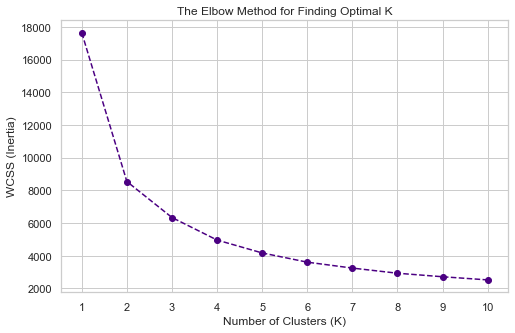

In [5]:
# --------------------------------------------
# Cell 5: The Elbow Method (Finding Optimal K)
# --------------------------------------------
print("--- Step 4: Computing Elbow Metric for Optimal K ---")

wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(rfm_scaled_df)
    wcss.append(kmeans.inertia_)

# Generate the WCSS Elbow Curve Plot
plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='indigo')
plt.title('The Elbow Method for Finding Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(k_range)
plt.show()

In [6]:
# -------------------------------------------------------
# Cell 6: Running K-Means and Evaluating Silhouette Score
# -------------------------------------------------------
# Selecting K=4 based on the typical elbow bend point for this specific dataset
optimal_k = 4 
print(f"--- Step 5: Clustering Profiles with K={optimal_k} ---")

kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(rfm_scaled_df)

# Route assigned label categories directly back to raw and adjusted DataFrames
rfm['Cluster'] = cluster_labels
rfm_scaled_df['Cluster'] = cluster_labels

# Compute global silhouette separation quality check
sil_avg = silhouette_score(rfm_scaled, cluster_labels)
print(f"Global Model Silhouette Coefficient: {sil_avg:.4f}")

--- Step 5: Clustering Profiles with K=4 ---
Global Model Silhouette Coefficient: 0.3618


In [7]:
# -----------------------------------
# Cell 7: Business Profiles Analysis
# -----------------------------------
print("--- Step 6: Customer Segment Behavioral Matrices ---")

# Evaluate mean operational footprints across each distinct cluster category
cluster_profile = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'Cluster': 'count'
}).rename(columns={'Cluster': 'SegmentSize'}).reset_index()

cluster_profile

--- Step 6: Customer Segment Behavioral Matrices ---


,Cluster,Recency,Frequency,Monetary,SegmentSize
0,0,386.373279,1.304437,318.417283,1961
1,1,26.996537,3.116017,868.085707,1155
2,2,233.420645,4.983226,1903.494166,1550
3,3,27.036304,19.049505,10863.001598,1212


--- Step 7: Producing Final Strategic Portfolio Charts ---


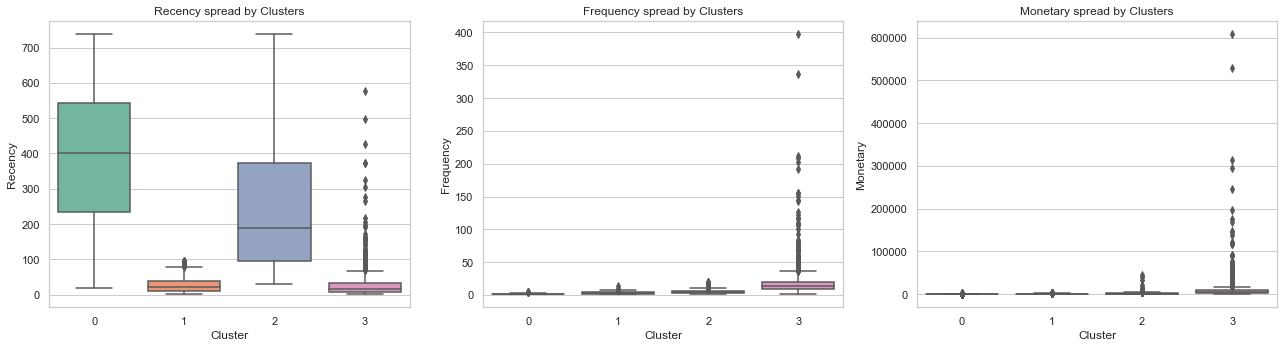

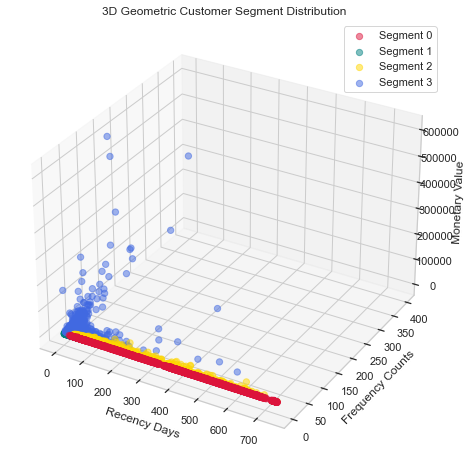

In [8]:
# --------------------------------
# Cell 8: Visualizing the Segments
# --------------------------------
print("--- Step 7: Producing Final Strategic Portfolio Charts ---")

# 1. Subplot Distributions (Boxplots)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(x='Cluster', y='Recency', data=rfm, ax=axes[0], palette='Set2')
axes[0].set_title('Recency spread by Clusters')

sns.boxplot(x='Cluster', y='Frequency', data=rfm, ax=axes[1], palette='Set2')
axes[1].set_title('Frequency spread by Clusters')

sns.boxplot(x='Cluster', y='Monetary', data=rfm, ax=axes[2], palette='Set2')
axes[2].set_title('Monetary spread by Clusters')
plt.tight_layout()
plt.show()

# 2. 3D Cluster Visual Projection Space
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

colors = ['crimson', 'teal', 'gold', 'royalblue']
for cluster in range(optimal_k):
    ax.scatter(rfm[rfm['Cluster'] == cluster]['Recency'],
               rfm[rfm['Cluster'] == cluster]['Frequency'],
               rfm[rfm['Cluster'] == cluster]['Monetary'],
               c=colors[cluster], label=f'Segment {cluster}', s=40, alpha=0.5)

ax.set_xlabel('Recency Days')
ax.set_ylabel('Frequency Counts')
ax.set_zlabel('Monetary Value')
ax.set_title('3D Geometric Customer Segment Distribution')
ax.legend()
plt.show()